# Toy Models of Superposition

This notebook includes the toy model training framework used to generate most of the results in the "Toy Models of Superposition" paper.

The main useful improvement over a basic PyTorch tiny autoencoder is the ability to batch train many models with varying sparsity at once, which is much more efficient than training them one at a time.

This notebook is designed to run in Google Colab's Python 3.7 environment.

In [1]:
!pip install einops matplotlib numpy pandas plotly tqdm torch

In [2]:
import torch
from torch import nn
from torch.nn import functional as F

from typing import Optional

from dataclasses import dataclass, replace
import numpy as np
import einops

from tqdm.notebook import trange

import time
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import matplotlib.pyplot as plt

In [3]:
@dataclass
class Config:
  n_features: int
  n_hidden: int

  # We optimize n_instances models in a single training loop
  # to let us sweep over sparsity or importance curves
  # efficiently.

  # We could potentially use torch.vmap instead.
  n_instances: int

class Model(nn.Module):
  def __init__(self,
               config,
               feature_probability: Optional[torch.Tensor] = None,
               importance: Optional[torch.Tensor] = None,
               device='cuda'):
    super().__init__()
    self.config = config
    self.W = nn.Parameter(torch.empty((config.n_instances, config.n_features, config.n_hidden), device=device))
    nn.init.xavier_normal_(self.W)
    self.b_final = nn.Parameter(torch.zeros((config.n_instances, config.n_features), device=device))

    if feature_probability is None:
      feature_probability = torch.ones(())
    self.feature_probability = feature_probability.to(device)
    if importance is None:
      importance = torch.ones(())
    self.importance = importance.to(device)

  def forward(self, features):
    # features: [..., instance, n_features]
    # W: [instance, n_features, n_hidden]
    hidden = torch.einsum("...if,ifh->...ih", features, self.W)
    out = torch.einsum("...ih,ifh->...if", hidden, self.W)
    out = out + self.b_final
    out = F.relu(out)
    return out

  def generate_batch(self, n_batch):
    feat = torch.rand((n_batch, self.config.n_instances, self.config.n_features), device=self.W.device)
    batch = torch.where(
        torch.rand((n_batch, self.config.n_instances, self.config.n_features), device=self.W.device) <= self.feature_probability,
        feat,
        torch.zeros((), device=self.W.device),
    )
    return batch

In [29]:
def linear_lr(step, steps):
  return (1 - (step / steps))

def constant_lr(*_):
  return 1.0

def cosine_decay_lr(step, steps):
  return np.cos(0.5 * np.pi * step / (steps - 1))

def optimize(model,
             render=False,
             n_batch=1024,
             steps=10_000,
             print_freq=100,
             lr=1e-3,
             lr_scale=constant_lr,
             hooks=[],
             snapshot_steps= None,):
  cfg = model.config

  opt = torch.optim.AdamW(list(model.parameters()), lr=lr)

  start = time.time()
  if snapshot_steps is None:
    snapshot_steps = []
  W_snaps = {}
  with trange(steps) as t:
    for step in t:
      step_lr = lr * lr_scale(step, steps)
      for group in opt.param_groups:
        group['lr'] = step_lr
      opt.zero_grad(set_to_none=True)
      batch = model.generate_batch(n_batch)
      out = model(batch)
      error = (model.importance*(batch.abs() - out)**2)
      loss = einops.reduce(error, 'b i f -> i', 'mean').sum()
      loss.backward()
      opt.step()
      if step in snapshot_steps:
        W_snaps[step] = model.W.detach().cpu().numpy().copy()

      if hooks:
        hook_data = dict(model=model,
                         step=step,
                         opt=opt,
                         error=error,
                         loss=loss,
                         lr=step_lr)
        for h in hooks:
          h(hook_data)
      if step % print_freq == 0 or (step + 1 == steps):
        t.set_postfix(
            loss=loss.item() / cfg.n_instances,
            lr=step_lr,
        )
  return W_snaps

In [30]:
if torch.cuda.is_available():
  DEVICE = 'cuda'
else:
  DEVICE = 'cpu'

## Introduction Figure

Reproducing a version of the figure from the introduction, although with a slightly different version of the code.

In [31]:
config = Config(
    n_features = 5,
    n_hidden = 2,
    n_instances = 10,
)

model = Model(
    config=config,
    device=DEVICE,
    # Exponential feature importance curve from 1 to 1/100
    importance = (0.9**torch.arange(config.n_features))[None, :],
    # Sweep feature frequency across the instances from 1 (fully dense) to 1/20
    feature_probability = (20 ** -torch.linspace(0, 1, config.n_instances))[:, None]
)

In [32]:
snapshot_steps = {0, 200, 1000, 5000, 20000}
optimize(model, snapshot_steps=snapshot_steps)

  0%|          | 0/10000 [00:00<?, ?it/s]

{0: array([[[-0.10287289,  0.08266956],
         [-0.05370397,  0.18036886],
         [-0.01959353,  0.0202867 ],
         [ 0.3632876 ,  0.1573667 ],
         [ 0.16329764, -0.00567973]],
 
        [[ 0.14753693, -0.56378263],
         [ 0.07857917, -0.10726603],
         [-0.11297803,  0.1984467 ],
         [-0.20324333,  0.0628121 ],
         [ 0.06965158,  0.0209373 ]],
 
        [[ 0.00827009,  0.52190053],
         [-0.04219295, -0.03777256],
         [-0.07168513, -0.21562392],
         [ 0.39089897,  0.4773566 ],
         [ 0.44953296, -0.06899901]],
 
        [[-0.29264036,  0.43795562],
         [-0.12952948,  0.15007442],
         [ 0.26849705,  0.47069675],
         [-0.265323  , -0.01241687],
         [-0.13788511,  0.24546756]],
 
        [[ 0.08596911,  0.08334751],
         [ 0.34755203, -0.10679322],
         [ 0.27353826, -0.10791336],
         [-0.36502385,  0.13839257],
         [ 0.12517549, -0.05632462]],
 
        [[-0.16545959, -0.17009406],
         [-0.5569015

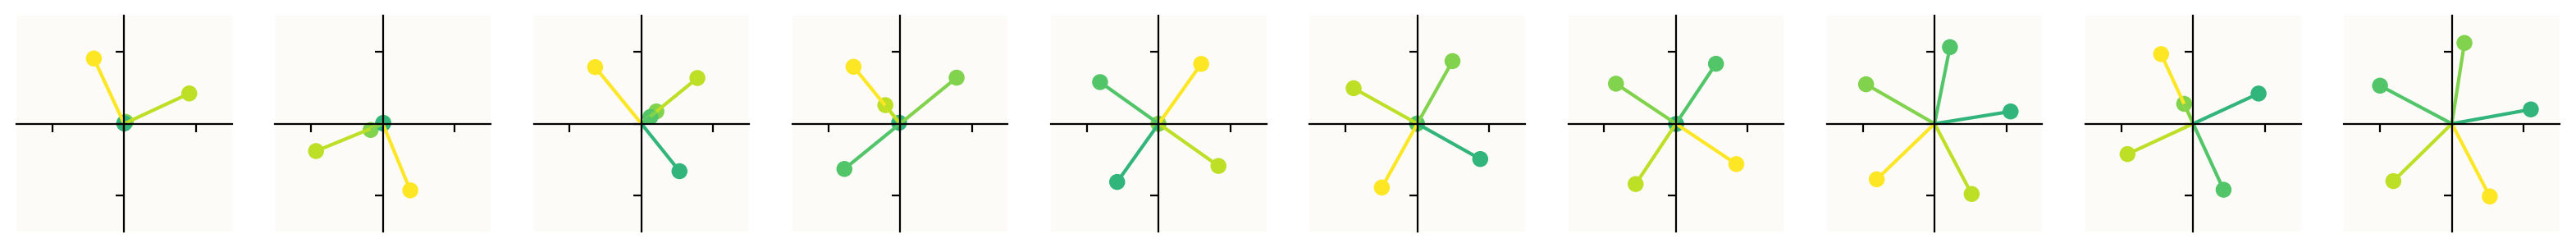

In [33]:
def plot_intro_diagram(model):
  from matplotlib import colors  as mcolors
  from matplotlib import collections  as mc
  cfg = model.config
  WA = model.W.detach()
  N = len(WA[:,0])
  sel = range(config.n_instances) # can be used to highlight specific sparsity levels
  plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.viridis(model.importance[0].cpu().numpy()))
  plt.rcParams['figure.dpi'] = 200
  fig, axs = plt.subplots(1,len(sel), figsize=(2*len(sel),2))
  for i, ax in zip(sel, axs):
      W = WA[i].cpu().detach().numpy()
      colors = [mcolors.to_rgba(c)
            for c in plt.rcParams['axes.prop_cycle'].by_key()['color']]
      ax.scatter(W[:,0], W[:,1], c=colors[0:len(W[:,0])])
      ax.set_aspect('equal')
      ax.add_collection(mc.LineCollection(np.stack((np.zeros_like(W),W), axis=1), colors=colors))

      z = 1.5
      ax.set_facecolor('#FCFBF8')
      ax.set_xlim((-z,z))
      ax.set_ylim((-z,z))
      ax.tick_params(left = True, right = False , labelleft = False ,
                  labelbottom = False, bottom = True)
      for spine in ['top', 'right']:
          ax.spines[spine].set_visible(False)
      for spine in ['bottom','left']:
          ax.spines[spine].set_position('center')
  plt.show()

plot_intro_diagram(model)

# Visualizing features across varying sparsity

In [34]:
config = Config(
    n_features = 100,
    n_hidden = 20,
    n_instances = 20,
)

model = Model(
    config=config,
    device=DEVICE,
    # Exponential feature importance curve from 1 to 1/100
    importance = (100 ** -torch.linspace(0, 1, config.n_features))[None, :],
    # Sweep feature frequency across the instances from 1 (fully dense) to 1/20
    feature_probability = (20 ** -torch.linspace(0, 1, config.n_instances))[:, None]
)

In [35]:
snapshot_steps = {0, 200, 1000, 5000, 20000}
optimize(model, snapshot_steps=snapshot_steps)

  0%|          | 0/10000 [00:00<?, ?it/s]

{0: array([[[ 1.07748564e-02, -3.90684493e-02,  2.60569695e-02, ...,
           7.08281249e-02, -1.22367814e-02,  4.45050634e-02],
         [ 2.80827750e-02, -3.21454480e-02, -1.66301914e-02, ...,
          -2.07283124e-02, -2.97908168e-02, -7.49909144e-04],
         [-4.28958349e-02, -1.86381638e-02, -1.37241324e-02, ...,
          -4.34578881e-02,  1.24654463e-02,  1.01775993e-02],
         ...,
         [ 3.11180819e-02, -7.10234558e-03, -3.37270042e-03, ...,
          -1.73911545e-02, -2.13162582e-02,  6.18108101e-02],
         [ 2.14296021e-03,  1.28592281e-02,  3.58989136e-03, ...,
          -8.75885319e-03,  3.71138379e-02, -1.71655361e-02],
         [ 2.02693585e-02,  1.55281392e-03,  1.59798134e-02, ...,
          -5.95153719e-02, -4.18155603e-02,  1.24596553e-02]],
 
        [[ 1.21655446e-02, -1.55895101e-02, -1.06322337e-02, ...,
           1.03632230e-02, -5.08368202e-02, -1.56659745e-02],
         [ 2.82242969e-02, -1.81108266e-02,  4.15606946e-02, ...,
          -1.97776

In [36]:
def render_features(model, which=np.s_[:]):
  cfg = model.config
  W = model.W.detach()
  W_norm = W / (1e-5 + torch.linalg.norm(W, 2, dim=-1, keepdim=True))

  interference = torch.einsum('ifh,igh->ifg', W_norm, W)
  interference[:, torch.arange(cfg.n_features), torch.arange(cfg.n_features)] = 0

  polysemanticity = torch.linalg.norm(interference, dim=-1).cpu()
  net_interference = (interference**2 * model.feature_probability[:, None, :]).sum(-1).cpu()
  norms = torch.linalg.norm(W, 2, dim=-1).cpu()

  WtW = torch.einsum('sih,soh->sio', W, W).cpu()

  # width = weights[0].cpu()
  # x = torch.cumsum(width+0.1, 0) - width[0]
  x = torch.arange(cfg.n_features)
  width = 0.9

  which_instances = np.arange(cfg.n_instances)[which]
  fig = make_subplots(rows=len(which_instances),
                      cols=2,
                      shared_xaxes=True,
                      vertical_spacing=0.02,
                      horizontal_spacing=0.1)
  for (row, inst) in enumerate(which_instances):
    fig.add_trace(
        go.Bar(x=x,
              y=norms[inst],
              marker=dict(
                  color=polysemanticity[inst],
                  cmin=0,
                  cmax=1
              ),
              width=width,
        ),
        row=1+row, col=1
    )
    data = WtW[inst].numpy()
    fig.add_trace(
        go.Image(
            z=plt.cm.coolwarm((1 + data)/2, bytes=True),
            colormodel='rgba256',
            customdata=data,
            hovertemplate='''\
In: %{x}<br>
Out: %{y}<br>
Weight: %{customdata:0.2f}
'''
        ),
        row=1+row, col=2
    )

  fig.add_vline(
    x=(x[cfg.n_hidden-1]+x[cfg.n_hidden])/2,
    line=dict(width=0.5),
    col=1,
  )

  # fig.update_traces(marker_size=1)
  fig.update_layout(showlegend=False,
                    width=600,
                    height=100*len(which_instances),
                    margin=dict(t=0, b=0))
  fig.update_xaxes(visible=False)
  fig.update_yaxes(visible=False)
  return fig

In [37]:
fig = render_features(model, np.s_[::2])
fig.update_layout()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'cmax': 1,
                         'cmin': 0,
                         'color': {'bdata': ('n6ELPGm0LDxB7wg8gKpVPPcLdTztzT' ... '+WV38/uxyAP8VXgD/iQYA/UR+APw=='),
                                   'dtype': 'f4'}},
              'type': 'bar',
              'width': 0.9,
              'x': {'bdata': ('AAECAwQFBgcICQoLDA0ODxAREhMUFR' ... '9QUVJTVFVWV1hZWltcXV5fYGFiYw=='),
                    'dtype': 'i1'},
              'xaxis': 'x',
              'y': {'bdata': ('Jf5/P6P7fz+zAIA/B/F/P6Hrfz8A7n' ... 'srtDI7NkM1O6HeQzuqmjQ7q7APOw=='),
                    'dtype': 'f4'},
              'yaxis': 'y'},
             {'colormodel': 'rgba256',
              'customdata': {'bdata': ('Sfx/PwCSJ7kAAOO2AMKtuAAw3rcABI' ... 'YQhJY2JG+9NqqJ0zZ9RMA2sk2hNg=='),
                             'dtype': 'f4',
                             'shape': '100, 100'},
              'hovertemplate': 'In: %{x}<br>\nOut: %{y}<br>\nWeight: %{customdata:0.2f}\n',
              'type': 'image',
              'xaxis': 'x2',
              'yaxis': 'y2',
              'z': {'bdata': ('swMm/9zc3f/c3N3/3Nzd/9zc3f/d3N' ... '/d3Nv/3dzb/93c2//d3Nv/3dzb/w=='),
                    'dtype': 'u1',
                    'shape': '100, 100, 4'}},
             {'marker': {'cmax': 1,
                         'cmin': 0,
                         'color': {'bdata': ('WbVDPLHANTzBfTU8L3GIPCmmfTxkpk' ... '/2/IA/Db9+P7mWgT+uJYE/VKKCPw=='),
                                   'dtype': 'f4'}},
              'type': 'bar',
              'width': 0.9,
              'x': {'bdata': ('AAECAwQFBgcICQoLDA0ODxAREhMUFR' ... '9QUVJTVFVWV1hZWltcXV5fYGFiYw=='),
                    'dtype': 'i1'},
              'xaxis': 'x3',
              'y': {'bdata': ('3yqAPxIhgD8RIYA/TD+APyEpgD99LI' ... 'sF/PM60nryOkUhDTuhTyo7L+AROw=='),
                    'dtype': 'f4'},
              'yaxis': 'y3'},
             {'colormodel': 'rgba256',
              'customdata': {'bdata': ('zVWAPwBwMrkA2I23ALwluAAYqTgACI' ... 'ZIdhC0mIfNNQ94JTb/DFE1cj+mNg=='),
                             'dtype': 'f4',
                             'shape': '100, 100'},
              'hovertemplate': 'In: %{x}<br>\nOut: %{y}<br>\nWeight: %{customdata:0.2f}\n',
              'type': 'image',
              'xaxis': 'x4',
              'yaxis': 'y4',
              'z': {'bdata': ('swMm/9zc3f/c3N3/3Nzd/93c2//c3N' ... '/c3N3/3dzb/93c2//d3Nv/3dzb/w=='),
                    'dtype': 'u1',
                    'shape': '100, 100, 4'}},
             {'marker': {'cmax': 1,
                         'cmin': 0,
                         'color': {'bdata': ('DwBcPMRofjwXcoA8UFCSPNrIcjwkX6' ... '8P+J8/q3mfP5+xlj8X+6A/bnWiPw=='),
                                   'dtype': 'f4'}},
              'type': 'bar',
              'width': 0.9,
              'x': {'bdata': ('AAECAwQFBgcICQoLDA0ODxAREhMUFR' ... '9QUVJTVFVWV1hZWltcXV5fYGFiYw=='),
                    'dtype': 'i1'},
              'xaxis': 'x5',
              'y': {'bdata': ('yE+AP+ZVgD/uV4A/KlmAP+tGgD+EcY' ... 'vXxqM7moGpO/v6VTvX1U87zJHAOw=='),
                    'dtype': 'f4'},
              'yaxis': 'y5'},
             {'colormodel': 'rgba256',
              'customdata': {'bdata': ('wJ+APwDqjjkATH84AMLwOQBl+bcABb' ... 'eIVrM3afqDNikaDbf1mHA2A9sQOA=='),
                             'dtype': 'f4',
                             'shape': '100, 100'},
              'hovertemplate': 'In: %{x}<br>\nOut: %{y}<br>\nWeight: %{customdata:0.2f}\n',
              'type': 'image',
              'xaxis': 'x6',
              'yaxis': 'y6',
              'z': {'bdata': ('swMm/93c2//d3Nv/3dzb/9zc3f/d3N' ... '/d3Nv/3dzb/9zc3f/d3Nv/3dzb/w=='),
                    'dtype': 'u1',
                    'shape': '100, 100, 4'}},
             {'marker': {'cmax': 1,
                         'cmin': 0,
                         'color': {'bdata': ('uqJzPKbjUTxLAmA82aSDPKMvhDzkxH' ... '8R6LE/WISxPwYGrz8I3rI/DA6zPw=='),
                                   'dtype': 'f4'}},
              'type': 'bar

# Feature geometry

In [38]:
config = Config(
    n_features = 200,
    n_hidden = 20,
    n_instances = 20,
)

model = Model(
    config=config,
    device=DEVICE,
    # For this experiment, use constant importance.

    # Sweep feature frequency across the instances from 1 (fully dense) to 1/20
    feature_probability = (20 ** -torch.linspace(0, 1, config.n_instances))[:, None]
)

In [39]:
snapshot_steps = {0, 200, 1000, 5000, 20000}
W_snaps = optimize(model, snapshot_steps=snapshot_steps)

  0%|          | 0/10000 [00:00<?, ?it/s]

In [40]:
fig = px.line(
    x=1/model.feature_probability[:, 0].cpu(),
    y=(model.config.n_hidden/(torch.linalg.matrix_norm(model.W.detach(), 'fro')**2)).cpu(),
    log_x=True,
    markers=True,
)
fig.update_xaxes(title="1/(1-S)")
fig.update_yaxes(title=f"m/||W||_F^2")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'x=%{x}<br>y=%{y}<extra></extra>',
              'legendgroup': '',
              'line': {'color': '#636efa', 'dash': 'solid'},
              'marker': {'symbol': 'circle'},
              'mode': 'lines+markers',
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'scatter',
              'x': {'bdata': ('AACAPx3clT/wc68/rWrNP21/8D/0yA' ... 'FBPFAqQUpmR0H3c2lBOqmIQQAAoEE='),
                    'dtype': 'f4'},
              'xaxis': 'x',
              'y': {'bdata': ('jX2AP2wTgD+GPXE/dq9ZP9WFGD8rqQ' ... 'E+a0VVPjUyPz5w1y0+HX8bPvyICz4='),
                    'dtype': 'f4'},
              'yaxis': 'y'}],
    'layout': {'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': '1/(1-S)'}, 'type': 'log'},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'm/||W||_F^2'}}}
})

In [41]:
@torch.no_grad()
def compute_dimensionality(W):
  norms = torch.linalg.norm(W, 2, dim=-1)
  W_unit = W / torch.clamp(norms[:, :, None], 1e-6, float('inf'))

  interferences = (torch.einsum('eah,ebh->eab', W_unit, W)**2).sum(-1)

  dim_fracs = (norms**2/interferences)
  return dim_fracs.cpu()

In [42]:
dim_fracs = compute_dimensionality(model.W)

In [43]:
fig = go.Figure()

density = model.feature_probability[:, 0].cpu()
W = model.W.detach()

for a,b in [(1,2), (2,3), (2,5), (2,6), (2,7)]:
    val = a/b
    fig.add_hline(val, line_color="purple", opacity=0.2, annotation=dict(text=f"{a}/{b}"))

for a,b in [(5,6), (4,5), (3,4), (3,8), (3,12), (3,20)]:
    val = a/b
    fig.add_hline(val, line_color="blue", opacity=0.2, annotation=dict(text=f"{a}/{b}", x=0.05))

for i in range(len(W)):
    fracs_ = dim_fracs[i]
    N = fracs_.shape[0]
    xs = 1/density
    if i!= len(W)-1:
        dx = xs[i+1]-xs[i]
    fig.add_trace(
        go.Scatter(
            x=1/density[i]*np.ones(N)+dx*np.random.uniform(-0.1,0.1,N),
            y=fracs_,
            marker=dict(
                color='black',
                size=1,
                opacity=0.5,
            ),
            mode='markers',
        )
    )

fig.update_xaxes(
    type='log',
    title='1/(1-S)',
    showgrid=False,
)
fig.update_yaxes(
    showgrid=False
)
fig.update_layout(showlegend=False)

/var/folders/cj/w1z0mn8d7f969q2nztm25g9h0000gn/T/ipykernel_34841/3173330410.py:22: DeprecationWarning:

__array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': 'black', 'opacity': 0.5, 'size': 1},
              'mode': 'markers',
              'type': 'scatter',
              'x': {'bdata': ('8vVptaQC8D9zIBkVzBPwP5ScFa+7p+' ... 'axC/A/0CuUS7U48D+dpzTwDZ/vPw=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('DEOTPbP5+T1klz8+vqvdPfSJ7T1/7L' ... '0+n1iwPeiJSz25vck9t5IKPkIZPz4='),
                    'dtype': 'f4'}},
             {'marker': {'color': 'black', 'opacity': 0.5, 'size': 1},
              'mode': 'markers',
              'type': 'scatter',
              'x': {'bdata': ('Poc7xJN78j9Kx0S8EX3yPyPl5GdD0f' ... 'o7+fI/zCYECpa88j8Ezku6lrHyPw=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('Yhc9PaEnuz3qugY+WWGwPZVbqD2Ij0' ... 'E9G+cFPql5LT492AI+Vlv0PXt9Kz4='),
                    'dtype': 'f4'}},
             {'marker': {'color': 'black', 'opacity': 0.5, 'size': 1},
              'mode': 'markers',
              'type': 'scatter',
              'x': {'bdata': ('TOpKeCkT9j9twXAFFR32P+L8Dhy5mv' ... 'wWqvU/4DMR7nNH9j9G2iQb9kz2Pw=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('ONMGPZCdMz3xXhw9glowPx/vTz3H/9' ... 'c9G6NdPQYPMT9eOTg9JpyDPfgfGD0='),
                    'dtype': 'f4'}},
             {'marker': {'color': 'black', 'opacity': 0.5, 'size': 1},
              'mode': 'markers',
              'type': 'scatter',
              'x': {'bdata': ('ScLvmUh7+T83Frk13Oj5PzYCJPmNDf' ... 'U1xfk/cauujkj2+T/6IFCzSbr5Pw=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('jBgoP2pltDzr2mA8CkCpPJpaJT/U6g' ... 'I/ievSPP31MDwly4c80zZ7PDTISDw='),
                    'dtype': 'f4'}},
             {'marker': {'color': 'black', 'opacity': 0.5, 'size': 1},
              'mode': 'markers',
              'type': 'scatter',
              'x': {'bdata': ('i/FLCzbk/T85RnF72VL+P62p+5BzxP' ... 'l0pf0/9Mh1h5Gf/T+FRxbIkHL+Pw=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('O7T+PkjZAD95Rcg7D94EPJSIDDxYC+' ... 'k8Bk4fPLI7ETyliwc8mhf/Pnn25js='),
                    'dtype': 'f4'}},
             {'marker': {'color': 'black', 'opacity': 0.5, 'size': 1},
              'mode': 'markers',
              'type': 'scatter',
              'x': {'bdata': ('eblQXtO6AUCAS5QBE2EBQHT/sNt1YQ' ... 'q6ggFARRI2R6WRAUCBBL/tAtIBQA=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('baQAPwz9tzuQwbg7bs/KO7MBuDvSnv' ... '47dtizO/83vjvxx7M7BA/lO8blzDs='),
                    'dtype': 'f4'}},
             {'marker': {'color': 'black', 'opacity': 0.5, 'size': 1},
              'mode': 'markers',
              'type': 'scatter',
              'x': {'bdata': ('BslYhX/kBEBTtXweeO0EQG02re0m9A' ... 'a2fARAxi4gTLi/BECaIFSLWVoEQA=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('FZnMO+sNAD/hSp07bWgAP840uDs8VQ' ... '47xYuSO0MC1zvLqak7VgSdO0SYtDs='),
                    'dtype': 'f4'}},
             {'marker': {'color': 'black', 'opacity': 0.5, 'size': 1},
              'mode': 'markers',
              'type': 'scatter',
              'x': {'bdata': ('2dLIpP6ACECq6AVs3HoIQNRrAMMLJg' ... '/qIwhAycoPtQA2CEAMUmfpnBMIQA=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('6CzNOyErnDugBsM7jMKBO+2eCzwGQ9' ... 'g7lk/KO7t68zt7XgA/p73ROxJP1Ts='),
                    'dtype': 'f4'}},
             {'marker': {'color': 'black', 'opacity': 0.5, 'size': 1},
              'mode': 'markers',
              'type': 'scatter',
              'x': {'bdata': ('OuuacNZKDEDL0XaDCOsLQAN7cqKTcA' ... 'cExAtADclvG/TdC0CAl1iGTSUMQA=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('e7AbOSEOAD/nmCo5Fb7tOPSR/D5kKP' ... 's5Rq5JOS6CRDnXQgA/lbfuOAqqtjg='),
                    'dtype': 'f4'}},
             {'marker': {'color': 'black', 'opacity': 0.5, 'size': 1},
              'mode': 'markers',
              'type': 'scatter',
              'x': {'bdata': ('vmKoahTIEEDWS5RjPIYQQCoTiyvBuh' ... 'U6uxBAm8cael5tEEAZ5x6jm2YQQA=='),
                    'dtype

## Resolvent analysis: snapshots during training

This section adds simple resolvent heatmaps at multiple training checkpoints for each instance ("neural network") in the batch.

It only depends on the trained weight tensor `model.W` (shape `[n_instances, n_features, n_hidden]`).

In [44]:

import numpy as np
import matplotlib.pyplot as plt

def _resolvent_response_heatmap(A, n_lam=250, eta=1e-2, b=None):
    """
    Computes heatmap H of Re[x(λ)] where x(λ) = R(λ+iη; A_sym) b, column-normalized.
    Returns (lam_grid, H) with H shape [n, n_lam].
    """
    A = np.asarray(A, dtype=np.float64)
    n = A.shape[0]
    As = 0.5*(A + A.T)  # enforce symmetric part for a clean real λ sweep

    evals = np.linalg.eigvalsh(As)
    lam_min, lam_max = evals.min(), evals.max()
    pad = 0.2*(lam_max - lam_min + 1e-9)
    lam_grid = np.linspace(lam_min - pad, lam_max + pad, n_lam)

    if b is None:
        b = np.ones(n, dtype=np.complex128) / np.sqrt(n)
    else:
        b = np.asarray(b, dtype=np.complex128)

    X = np.zeros((n_lam, n), dtype=np.complex128)
    I = np.eye(n, dtype=np.complex128)
    As_c = As.astype(np.complex128)

    for k, lam in enumerate(lam_grid):
        z = lam + 1j*eta
        R = np.linalg.inv(z*I - As_c)
        x = R @ b
        x = x / (np.linalg.norm(x) + 1e-12)
        X[k] = x

    return lam_grid, np.real(X).T

def plot_resolvent_heatmap(A, title="", n_lam=250, eta=1e-2):
    lam_grid, H = _resolvent_response_heatmap(A, n_lam=n_lam, eta=eta)
    plt.figure(figsize=(7, 3.5))
    plt.imshow(H, aspect="auto", origin="lower",
               extent=[lam_grid[0], lam_grid[-1], 0, H.shape[0]-1])
    plt.title(title)
    plt.xlabel("λ")
    plt.ylabel("index")
    plt.colorbar()
    plt.show()

def grams_from_Wi(Wi):
    """
    Wi: [n_features, n_hidden]
    returns (G_feature, G_hidden)
    """
    Gf = Wi @ Wi.T
    Gh = Wi.T @ Wi
    return Gf, Gh


## To visualize eigenmodes you don’t usually plot the whole $ n\times n $ resolvent for every $ \lambda $; we plot some vector or slice derived from it, which necessarily has coordinates.

What we are plotting in your heatmaps is not “the resolvent” directly, but the resolvent acting on a probe:
$$
x(\lambda)=R(\lambda+i\eta)\,b,
\qquad
R(z)=(zI-A)^{-1}.
$$

Here:
- $R(z)$ is an $n\times n$ matrix,
- $b$ is a length-$n$ probe vector,
- $x(\lambda)$ is a length-$n$ vector.


So the heatmap’s y-axis index is just the coordinate $j$ of that vector $x_j(\lambda)$ in the standard basis (feature index if you used $WW^\top$, hidden index if you used $W^\top W$.

## Why do this at all?
Because it reveals eigenmodes. Using the eigendecomposition (symmetric case)
$$
A=\sum_k \lambda_k\, v_k v_k^\top,
$$
we get
$$
R(z)b=\sum_k \frac{v_k^\top b}{z-\lambda_k}\,v_k.
$$
Near $\lambda\approx \lambda_k$, the factor $\frac{1}{z-\lambda_k}$ blows up, so $x(\lambda)$ becomes dominated by $v_k$ (the eigenvector). The heatmap shows which coordinates are large in that eigenvector — that’s the “mode shape”.


In [53]:

# Example: run resolvent heatmaps on trained weights
# Requires you've already trained a `model` and have model.W available.
import matplotlib.pyplot as plt
import numpy as np

def plot_resolvent_grid_over_steps(
    W_snaps,
    instance_ids=None,
    steps=None,
    which="feature",
    eta=1e-2,
    n_lam=250,
    share_color_per_row=True,
    figsize_per_cell=(4.0, 2.6),
):
    """
    Grid of resolvent heatmaps:
      rows = instances
      cols = steps
    """
    all_steps = sorted(W_snaps.keys())
    if steps is None:
        steps = all_steps
    else:
        steps = [s for s in steps if s in W_snaps]

    W0 = W_snaps[steps[0]]
    n_instances = W0.shape[0]
    if instance_ids is None:
        instance_ids = [0, n_instances//2, n_instances-1]

    nrows = len(instance_ids)
    ncols = len(steps)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(figsize_per_cell[0]*ncols, figsize_per_cell[1]*nrows),
        squeeze=False
    )

    for r, i in enumerate(instance_ids):
        # Optional: fix color range per instance row to compare across time
        row_vmin, row_vmax = None, None
        if share_color_per_row:
            # precompute vmin/vmax over all steps for this instance
            vals = []
            for step in steps:
                Wi = W_snaps[step][i]
                Gf, Gh = grams_from_Wi(Wi)
                A = Gf if which == "feature" else Gh
                lam_grid, H = _resolvent_response_heatmap(A, n_lam=n_lam, eta=eta)
                vals.append(H)
            H_all = np.concatenate(vals, axis=1)  # concat along lambda axis
            row_vmin, row_vmax = np.percentile(H_all, [2, 98])

        for c, step in enumerate(steps):
            ax = axes[r, c]
            Wi = W_snaps[step][i]
            Gf, Gh = grams_from_Wi(Wi)
            A = Gf if which == "feature" else Gh

            lam_grid, H = _resolvent_response_heatmap(A, n_lam=n_lam, eta=eta)

            im = ax.imshow(
                H, aspect="auto", origin="lower",
                extent=[lam_grid[0], lam_grid[-1], 0, H.shape[0]-1],
                vmin=row_vmin, vmax=row_vmax
            )

            if r == 0:
                ax.set_title(f"step={step}")
            if c == 0:
                ax.set_ylabel(f"inst {i}\nidx")
            else:
                ax.set_yticks([])

            ax.set_xlabel("λ")

        # add one colorbar per row (rightmost axis)
        cb = fig.colorbar(im, ax=axes[r, :].tolist(), fraction=0.015, pad=0.01)

    fig.suptitle(f"Resolvent heatmaps over training | {which} Gram | eta={eta}", y=1.02)
    plt.tight_layout()
    plt.show()



/var/folders/cj/w1z0mn8d7f969q2nztm25g9h0000gn/T/ipykernel_34841/2407228593.py:83: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



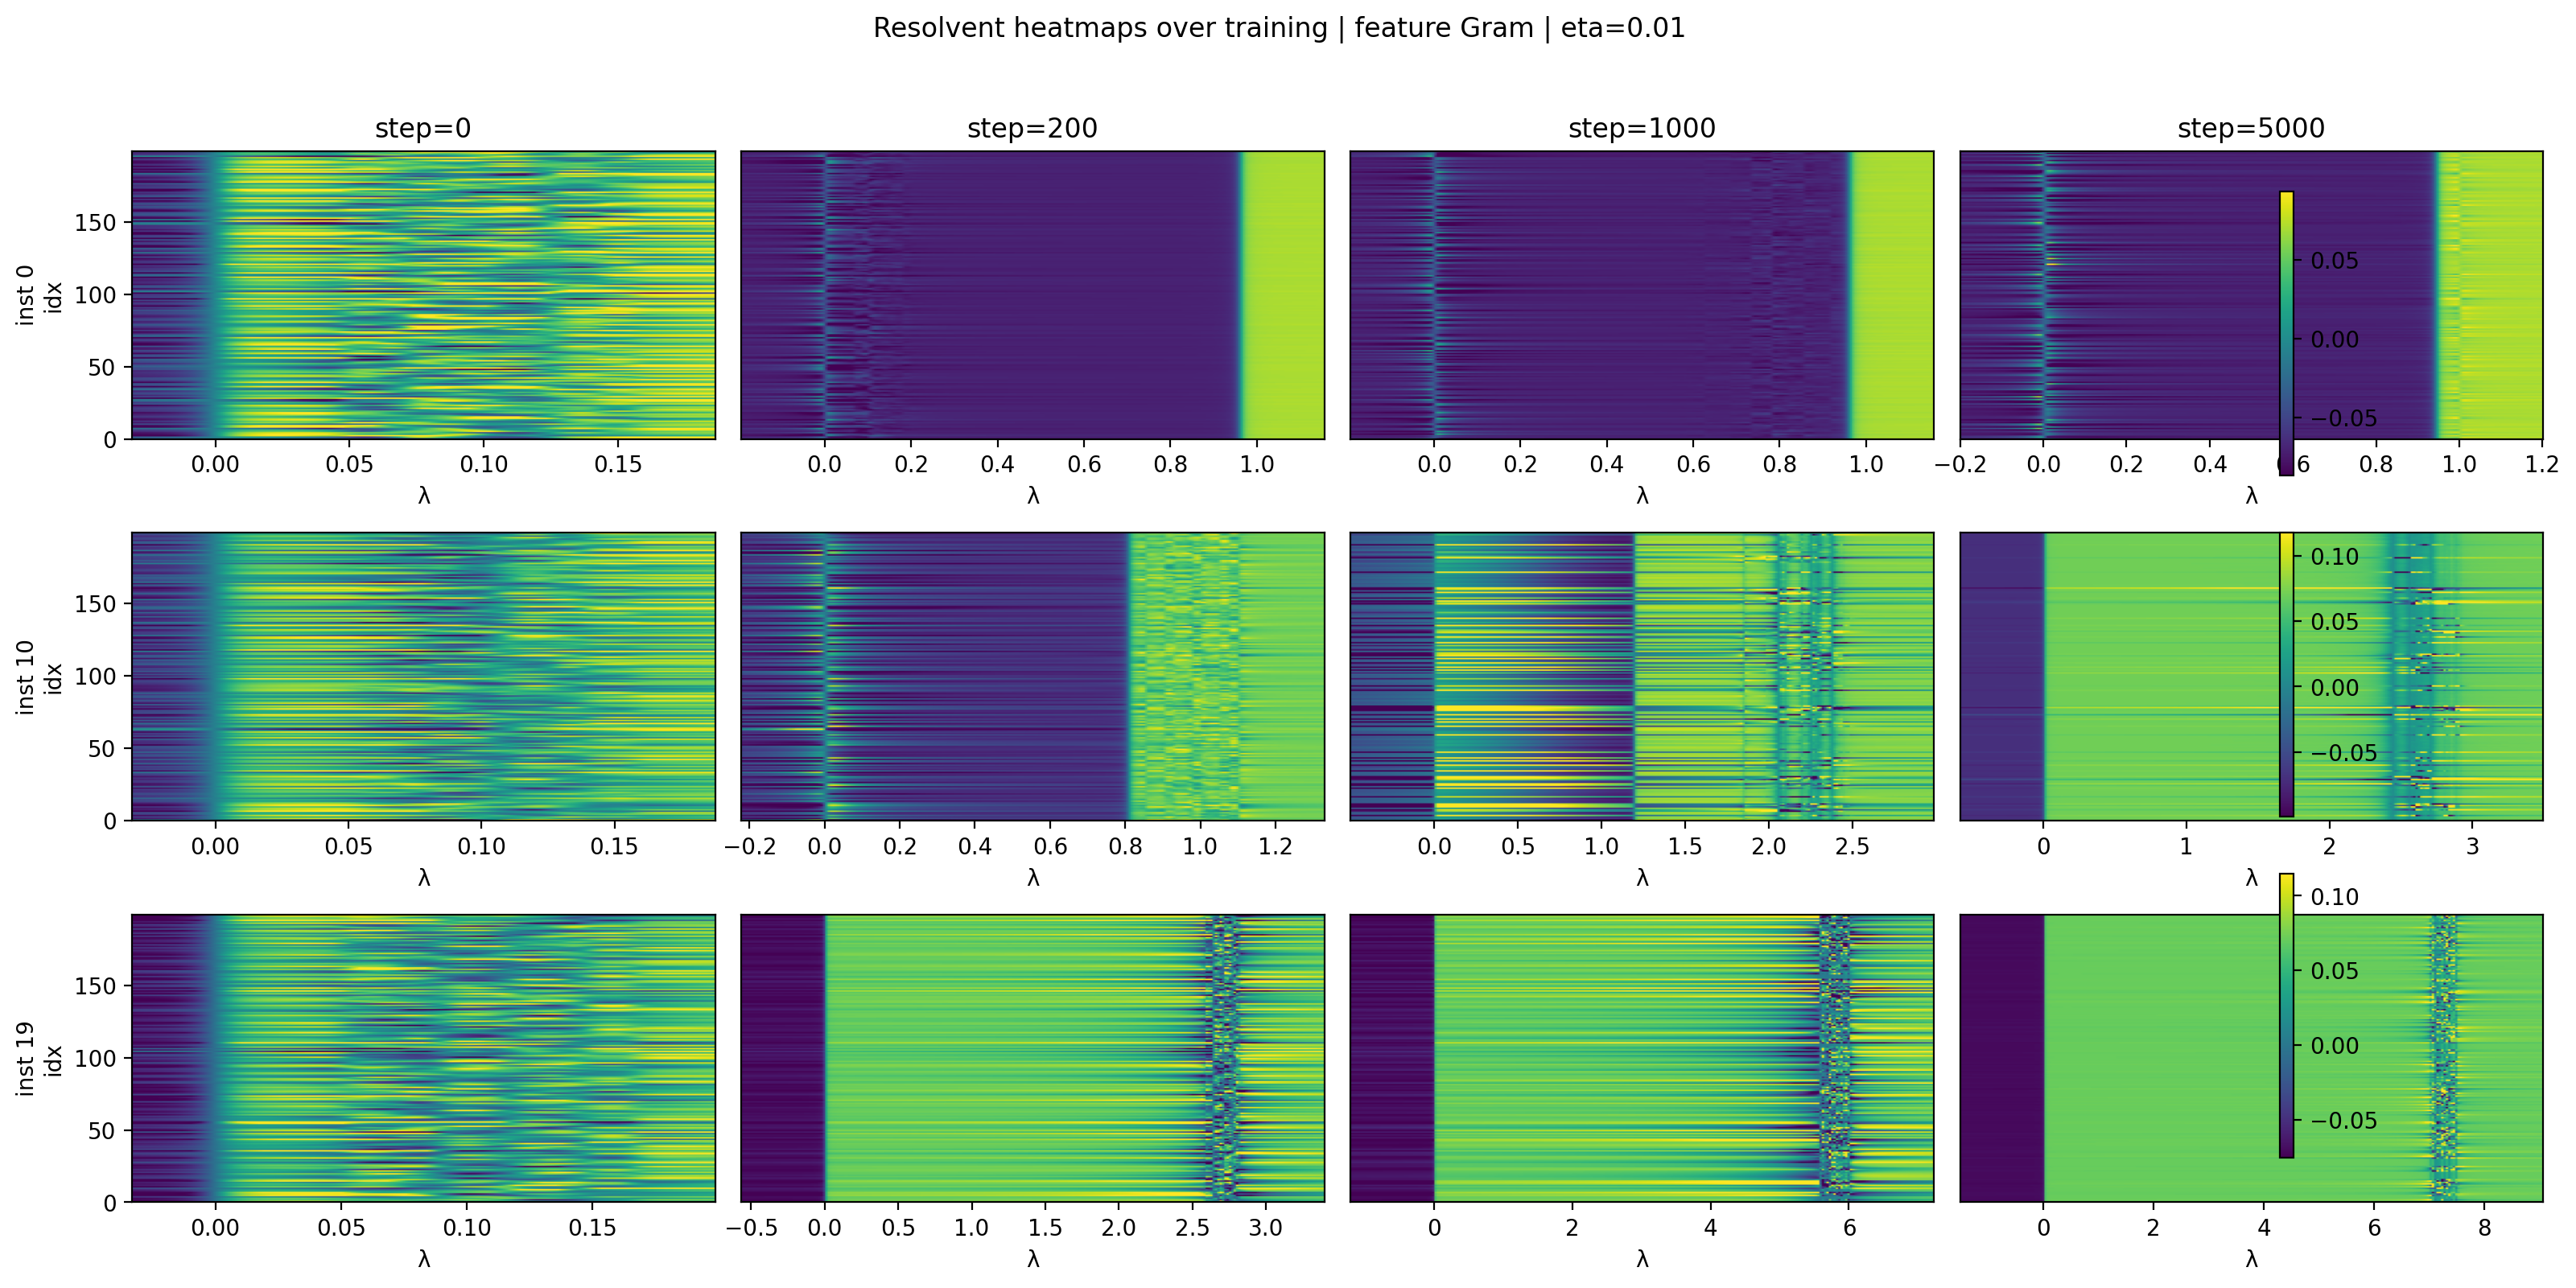

In [54]:
# After training, let's visualize the resolvent heatmaps:
plot_resolvent_grid_over_steps(W_snaps, which="feature", eta=1e-2, n_lam=250)

